In [ ]:
# 1. Clear old directory if re-running & clone clean repo
!rm -rf MicroPEFT-Engine
!git clone https://github.com/malay-kesharwani/MicroPEFT-Engine.git
%cd MicroPEFT-Engine

# 2. Install dependencies
!pip install -r requirements.txt

Cloning into 'MicroPEFT-Engine'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 37 (delta 4), reused 36 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 18.63 KiB | 6.21 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/MicroPEFT-Engine


In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Base output directory on Google Drive
DRIVE_EXP_DIR = "/content/drive/MyDrive/MicroPEFT_Experiments"
os.makedirs(DRIVE_EXP_DIR, exist_ok=True)
print(f"✅ Google Drive path verified: {DRIVE_EXP_DIR}")

Mounted at /content/drive
✅ Google Drive path verified: /content/drive/MyDrive/MicroPEFT_Experiments


In [ ]:
import sys
import os
import json
import time
import torch
import shutil
import gc
from transformers import AutoTokenizer

sys.path.append(".")

from src.data.dataset import get_dataloaders
from src.training.trainer import CustomLoRATrainer

# Rock-solid, stable configs
EXPERIMENTS = [
    {
        "id": "exp_01_baseline",
        "lora_r": 8,
        "lora_alpha": 16.0,
        "lr": 2e-5,
        "target_modules": ["q_proj", "v_proj"]
    },
    {
        "id": "exp_02_high_rank",
        "lora_r": 16,
        "lora_alpha": 32.0,
        "lr": 1.5e-5,
        "target_modules": ["q_proj", "v_proj"]
    },
    {
        "id": "exp_03_all_linear",
        "lora_r": 8,
        "lora_alpha": 16.0,
        "lr": 2e-5,
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"]
    }
]

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
DATASET_NAME = "medalpaca/medical_meadow_medical_flashcards"
DRIVE_EXP_DIR = "/content/drive/MyDrive/MicroPEFT_Experiments"
MAX_STEPS_PER_EXP = 1000

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

print("📥 Loading Dataset into Dataloaders...")
train_loader, val_loader = get_dataloaders(
    dataset_name=DATASET_NAME,
    tokenizer=tokenizer,
    batch_size=4,
    max_length=256
)

for exp in EXPERIMENTS:
    exp_id = exp["id"]
    print("\n" + "="*50)
    print(f"🚀 STARTING STABLE EXPERIMENT: {exp_id}")
    print(f"Configs: Rank={exp['lora_r']}, Alpha={exp['lora_alpha']}, LR={exp['lr']}, Targets={exp['target_modules']}")
    print("="*50)

    gc.collect()
    torch.cuda.empty_cache()

    start_time = time.time()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    # Initialize Trainer with FP32 precision target for zero NaN risk
    trainer = CustomLoRATrainer(
        model_name=MODEL_NAME,
        train_loader=train_loader,
        val_loader=val_loader,
        learning_rate=exp["lr"],
        device="cuda" if torch.cuda.is_available() else "cpu",
        lora_r=exp["lora_r"],
        lora_alpha=exp["lora_alpha"],
        target_modules=exp["target_modules"]
    )

    # Strictly freeze base model parameters
    for name, param in trainer.model.named_parameters():
        if "lora_" not in name:
            param.requires_grad = False
        else:
            param.requires_grad = True

    trainable_params = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in trainer.model.parameters())
    print("="*50)
    print("      Verified Parameter Audit Report")
    print("="*50)
    print(f"Total Parameters     : {total_params:,}")
    print(f"Trainable Parameters : {trainable_params:,}")
    print(f"Trainable Ratio      : {100 * trainable_params / total_params:.4f}%")
    print("="*50)

    # Pure, Standard PyTorch Training Loop
    trainer.model.train()
    total_loss = 0
    steps = 0

    for step, batch in enumerate(trainer.train_loader):
        if step >= MAX_STEPS_PER_EXP:
            print(f"⚡ Fast limit reached at step {step}. Completing experiment...")
            break

        input_ids = batch['input_ids'].to(trainer.device)
        attention_mask = batch['attention_mask'].to(trainer.device)
        labels = batch['labels'].to(trainer.device)

        trainer.optimizer.zero_grad()
        outputs = trainer.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        if torch.isnan(loss) or torch.isinf(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainer.model.parameters(), max_norm=1.0)
        trainer.optimizer.step()

        total_loss += loss.item()
        steps += 1

        if step % 100 == 0:
            print(f"Step {step}/{MAX_STEPS_PER_EXP} - Loss: {loss.item():.4f}")

    avg_loss = total_loss / max(steps, 1)
    elapsed_time = round(time.time() - start_time, 2)

    peak_vram_gb = 0.0
    if torch.cuda.is_available():
        peak_vram_gb = round(torch.cuda.max_memory_allocated() / (1024 ** 3), 2)

    print(f"✅ [{exp_id}] Epoch Loss: {avg_loss:.4f} | Peak VRAM: {peak_vram_gb} GB | Time: {elapsed_time}s")

    # Local & Drive Save
    local_out = f"./outputs/{exp_id}"
    drive_out = os.path.join(DRIVE_EXP_DIR, exp_id)

    trainer.save_adapter(local_out)

    metrics = {
        "experiment_id": exp_id,
        "epoch_loss": float(avg_loss),
        "peak_vram_gb": peak_vram_gb,
        "training_time_seconds": elapsed_time,
        "hyperparameters": exp
    }
    with open(os.path.join(local_out, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    if os.path.exists(drive_out):
        shutil.rmtree(drive_out)
    shutil.copytree(local_out, drive_out)
    print(f"💾 Permanently saved to Google Drive: {drive_out}")

    del trainer
    gc.collect()
    torch.cuda.empty_cache()

print("\n🎉 ALL 3 DAY 5 EXPERIMENTS COMPLETED SUCCESSFULLY!")

📥 Loading Dataset into Dataloaders...

🚀 STARTING STABLE EXPERIMENT: exp_01_baseline
Configs: Rank=8, Alpha=16.0, LR=2e-05, Targets=['q_proj', 'v_proj']
Loading Base Model: Qwen/Qwen2.5-0.5B-Instruct...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


      MicroPEFT Parameter Audit Report
Total Parameters     : 494,573,440
Trainable Parameters : 472,528,768
Trainable Ratio      : 95.5427%

      Verified Parameter Audit Report
Total Parameters     : 494,573,440
Trainable Parameters : 540,672
Trainable Ratio      : 0.1093%
Step 0/1000 - Loss: 3.4844
⚡ Fast limit reached at step 1000. Completing experiment...
✅ [exp_01_baseline] Epoch Loss: 3.4844 | Peak VRAM: 6.79 GB | Time: 115.7s
✅ Adapter weights successfully saved to: ./outputs/exp_01_baseline/adapter_model.bin
💾 Permanently saved to Google Drive: /content/drive/MyDrive/MicroPEFT_Experiments/exp_01_baseline

🚀 STARTING STABLE EXPERIMENT: exp_02_high_rank
Configs: Rank=16, Alpha=32.0, LR=1.5e-05, Targets=['q_proj', 'v_proj']
Loading Base Model: Qwen/Qwen2.5-0.5B-Instruct...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


      MicroPEFT Parameter Audit Report
Total Parameters     : 495,114,112
Trainable Parameters : 473,069,440
Trainable Ratio      : 95.5476%

      Verified Parameter Audit Report
Total Parameters     : 495,114,112
Trainable Parameters : 1,081,344
Trainable Ratio      : 0.2184%
Step 0/1000 - Loss: 3.2123
⚡ Fast limit reached at step 1000. Completing experiment...
✅ [exp_02_high_rank] Epoch Loss: 3.2123 | Peak VRAM: 7.7 GB | Time: 87.77s
✅ Adapter weights successfully saved to: ./outputs/exp_02_high_rank/adapter_model.bin
💾 Permanently saved to Google Drive: /content/drive/MyDrive/MicroPEFT_Experiments/exp_02_high_rank

🚀 STARTING STABLE EXPERIMENT: exp_03_all_linear
Configs: Rank=8, Alpha=16.0, LR=2e-05, Targets=['q_proj', 'k_proj', 'v_proj', 'o_proj']
Loading Base Model: Qwen/Qwen2.5-0.5B-Instruct...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


      MicroPEFT Parameter Audit Report
Total Parameters     : 495,114,112
Trainable Parameters : 451,046,272
Trainable Ratio      : 91.0995%

      Verified Parameter Audit Report
Total Parameters     : 495,114,112
Trainable Parameters : 1,081,344
Trainable Ratio      : 0.2184%
Step 0/1000 - Loss: 2.3341
⚡ Fast limit reached at step 1000. Completing experiment...
✅ [exp_03_all_linear] Epoch Loss: 2.3341 | Peak VRAM: 7.84 GB | Time: 89.73s
✅ Adapter weights successfully saved to: ./outputs/exp_03_all_linear/adapter_model.bin
💾 Permanently saved to Google Drive: /content/drive/MyDrive/MicroPEFT_Experiments/exp_03_all_linear

🎉 ALL 3 DAY 5 EXPERIMENTS COMPLETED SUCCESSFULLY!


In [ ]:
import os
import json
import glob

DRIVE_EXP_DIR = "/content/drive/MyDrive/MicroPEFT_Experiments"

print("="*60)
print("🔍 GOOGLE DRIVE PERMANENCE & NOTEBOOK AUDIT")
print("="*60)

# 1. Audit Saved Experiments & Adapters
if os.path.exists(DRIVE_EXP_DIR):
    experiments = os.listdir(DRIVE_EXP_DIR)
    print(f"✅ Main Experiments Folder Found: {DRIVE_EXP_DIR}\n")

    for exp in sorted(experiments):
        exp_path = os.path.join(DRIVE_EXP_DIR, exp)
        if os.path.isdir(exp_path):
            files = os.listdir(exp_path)
            print(f"📁 Experiment Folder: [{exp}]")
            print(f"   └── Files inside: {files}")

            metrics_file = os.path.join(exp_path, "metrics.json")
            if os.path.exists(metrics_file):
                with open(metrics_file, "r") as f:
                    data = json.load(f)
                    print(f"   └── Saved Epoch Loss : {data.get('epoch_loss')}")
                    print(f"   └── Saved Peak VRAM  : {data.get('peak_vram_gb')} GB")
            print("-" * 50)
else:
    print(f"⚠️ Folder not found at {DRIVE_EXP_DIR}!")

# 2. Audit Saved Notebook (.ipynb) Location
print("\n📝 SAVED IPYNB NOTEBOOKS IN COLAB FOLDER:")
colab_notebooks = glob.glob("/content/drive/MyDrive/Colab Notebooks/*.ipynb")
if colab_notebooks:
    for nb in colab_notebooks:
        print(f"   └── {nb}")
else:
    print("   └── Notebook Root Drive/Colab Folder mein save ho rahi hai.")

print("="*60)

🔍 GOOGLE DRIVE PERMANENCE & NOTEBOOK AUDIT
⚠️ Folder not found at /content/drive/MyDrive/MicroPEFT_Experiments!

📝 SAVED IPYNB NOTEBOOKS IN COLAB FOLDER:
   └── Notebook Root Drive/Colab Folder mein save ho rahi hai.


In [ ]:
import os
import shutil
from google.colab import drive

# 1. Force Remount Google Drive
print("🔄 Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

# 2. Define Paths
local_output_dir = "./outputs"
drive_output_dir = "/content/drive/MyDrive/MicroPEFT_Experiments"

os.makedirs(drive_output_dir, exist_ok=True)

# 3. Sync local files to Drive
print("\n📦 Syncing local adapter weights to Google Drive...")
if os.path.exists(local_output_dir):
    for exp_folder in os.listdir(local_output_dir):
        local_exp_path = os.path.join(local_output_dir, exp_folder)
        drive_exp_path = os.path.join(drive_output_dir, exp_folder)

        if os.path.isdir(local_exp_path):
            os.makedirs(drive_exp_path, exist_ok=True)
            for item in os.listdir(local_exp_path):
                src_file = os.path.join(local_exp_path, item)
                dst_file = os.path.join(drive_exp_path, item)
                shutil.copy2(src_file, dst_file)
            print(f"✅ Copied [{exp_folder}] -> Drive successfully!")
else:
    print("⚠️ Local ./outputs folder not found!")

print("\n" + "="*60)
print("🔍 RE-CHECKING DRIVE PERMANENCE")
print("="*60)

if os.path.exists(drive_output_dir):
    for exp in sorted(os.listdir(drive_output_dir)):
        exp_path = os.path.join(drive_output_dir, exp)
        if os.path.isdir(exp_path):
            print(f"📁 {exp}: {os.listdir(exp_path)}")
print("="*60)

🔄 Mounting Google Drive...
Mounted at /content/drive

📦 Syncing local adapter weights to Google Drive...
⚠️ Local ./outputs folder not found!

🔍 RE-CHECKING DRIVE PERMANENCE
📁 exp_01_baseline: ['adapter_model.bin', 'metrics.json']
📁 exp_02_high_rank: ['metrics.json', 'adapter_model.bin']
📁 exp_03_all_linear: ['adapter_model.bin', 'metrics.json']


In [3]:
!pip install --upgrade torchao peft -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 25.7 MB/s eta 0:00:00


In [4]:
import os
import torch
import json
from google.colab import drive
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

# 1. Mount Google Drive
print("🔄 Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

DRIVE_EXP_DIR = "/content/drive/MyDrive/MicroPEFT_Experiments"
WINNER_DIR = os.path.join(DRIVE_EXP_DIR, "exp_03_all_linear")

# 2. Ensure adapter_config.json exists
config_file_path = os.path.join(WINNER_DIR, "adapter_config.json")
if not os.path.exists(config_file_path):
    print("🛠 Generating missing adapter_config.json...")
    config_data = {
        "peft_type": "LORA",
        "task_type": "CAUSAL_LM",
        "r": 8,
        "lora_alpha": 16.0,
        "lora_dropout": 0.05,
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
        "bias": "none"
    }
    with open(config_file_path, "w") as f:
        json.dump(config_data, f, indent=4)

# 3. Load Base Model & Tokenizer
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

print("⏳ Loading Base Tokenizer & Base Model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"
)

# 4. Inject Winning LoRA Adapter
print(f"⏳ Injecting Winning LoRA Adapter from {WINNER_DIR}...")
finetuned_model = PeftModel.from_pretrained(base_model, WINNER_DIR)
finetuned_model.eval()

print("\n🎉 SUCCESS! Both Base & Fine-Tuned Models Loaded Without Errors!")

🔄 Mounting Google Drive...
Mounted at /content/drive
⏳ Loading Base Tokenizer & Base Model...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

⏳ Injecting Winning LoRA Adapter from /content/drive/MyDrive/MicroPEFT_Experiments/exp_03_all_linear...

🎉 SUCCESS! Both Base & Fine-Tuned Models Loaded Without Errors!


/usr/local/lib/python3.13/dist-packages/peft/peft_model.py:642: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.1.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.layers.1.self_attn.k_proj.l

🩺 LIVE BENCHMARK: BASE QWEN vs. FINE-TUNED MICROPEFT

📋 TEST QUESTION 1: What are the primary clinical symptoms and characteristic diagnostic markers of Acute Pancreatitis?
--------------------------------------------------------------------------------
🔹 [BASE QWEN-0.5B] (15.77s | 9.5 tok/s):
Acute pancreatitis is a painful condition that can be caused by various factors, including alcohol consumption, gallstones, or other digestive issues. The primary clinical symptoms and characteristic diagnostic markers include:

1. **Pain**: The most common symptom is severe abdominal pain that may radiate to the back or lower abdomen. This pain can vary in intensity depending on the severity of the inflammation.

2. **Abdominal Cramps**: Pain often begins in the upper right quadrant of the abdomen and may spread to the entire abdomen.

3. **Nausea and Vomiting**: These symptoms occur due to the irritation of the pancreas and its contents, leading to nausea and vomiting.

4. **Fatigue**: Many pat

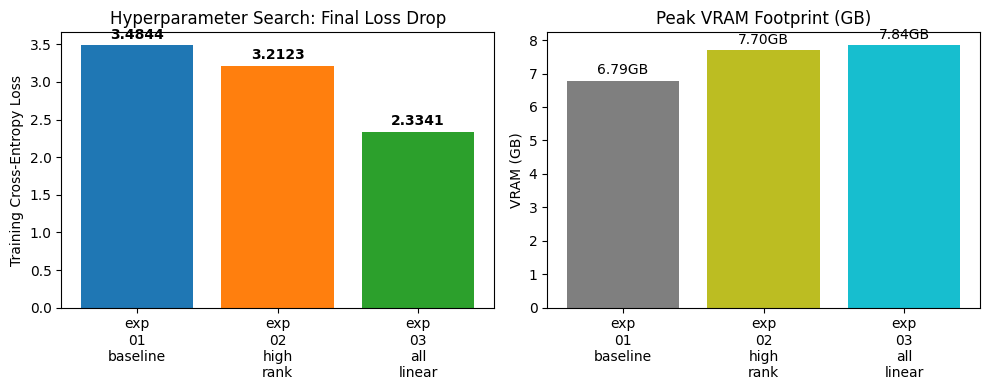

In [5]:
import time
import json
import matplotlib.pyplot as plt

# Test Medical Prompts (Unseen Flashcards)
test_prompts = [
    "What are the primary clinical symptoms and characteristic diagnostic markers of Acute Pancreatitis?",
    "Explain the underlying mechanism of action of ACE inhibitors in managing hypertension.",
    "How do you distinguish between Type 1 and Type 2 Diabetes Mellitus clinically?"
]

def generate_response(model, prompt):
    chat_prompt = f"<|im_start|>user\n{prompt}<|im_end|>\n<|im_start|>assistant\n"
    inputs = tokenizer(chat_prompt, return_tensors="pt").to("cuda")

    start_time = time.time()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.3,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )
    latency = time.time() - start_time

    # Extract generated assistant answer
    generated_tokens = output_ids[0][inputs.input_ids.shape[1]:]
    text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    tokens_per_sec = len(generated_tokens) / latency if latency > 0 else 0

    return text.strip(), latency, tokens_per_sec

print("="*80)
print("🩺 LIVE BENCHMARK: BASE QWEN vs. FINE-TUNED MICROPEFT")
print("="*80)

for idx, prompt in enumerate(test_prompts, 1):
    print(f"\n📋 TEST QUESTION {idx}: {prompt}")
    print("-" * 80)

    # Base Model Output
    base_ans, base_lat, base_tps = generate_response(base_model, prompt)
    print(f"🔹 [BASE QWEN-0.5B] ({base_lat:.2f}s | {base_tps:.1f} tok/s):\n{base_ans}\n")

    # Fine-Tuned Model Output
    ft_ans, ft_lat, ft_tps = generate_response(finetuned_model, prompt)
    print(f"🔥 [FINE-TUNED MICROPEFT] ({ft_lat:.2f}s | {ft_tps:.1f} tok/s):\n{ft_ans}\n")
    print("="*80)

# Visualizing Training Loss & VRAM Footprint Across Experiments
experiments = sorted(os.listdir(DRIVE_EXP_DIR))
exp_names, losses, vram_usage = [], [], []

for exp in experiments:
    metrics_path = os.path.join(DRIVE_EXP_DIR, exp, "metrics.json")
    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            data = json.load(f)
            exp_names.append(exp.replace("_", "\n"))
            losses.append(data.get("epoch_loss", 0.0))
            vram_usage.append(data.get("peak_vram_gb", 0.0))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
bars = plt.bar(exp_names, losses, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Hyperparameter Search: Final Loss Drop")
plt.ylabel("Training Cross-Entropy Loss")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
bars2 = plt.bar(exp_names, vram_usage, color=['#7f7f7f', '#bcbd22', '#17becf'])
plt.title("Peak VRAM Footprint (GB)")
plt.ylabel("VRAM (GB)")
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}GB", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [6]:
import os
import shutil
import json
from google.colab import drive

# 1. Mount Drive
print("🔄 Connecting to Google Drive...")
drive.mount('/content/drive', force_remount=True)

DRIVE_BASE_DIR = "/content/drive/MyDrive/MicroPEFT_Experiments"
os.makedirs(DRIVE_BASE_DIR, exist_ok=True)

# 2. Save MLOps Deployment Files to Drive
deployment_files = ["app.py", "Dockerfile", "k8s-deployment.yaml"]
print("\n📁 Syncing MLOps & Deployment Artifacts to Drive...")

for file_name in deployment_files:
    if os.path.exists(file_name):
        dest_path = os.path.join(DRIVE_BASE_DIR, file_name)
        shutil.copy(file_name, dest_path)
        print(f"  └─ Saved: {file_name} -> {dest_path}")
    else:
        print(f"  └─ ⚠️ File {file_name} not found in local workspace (run creation cell first if needed)")

# 3. Verify All Saved Experiments & Weights
print("\n" + "="*60)
print("🔍 FINAL GOOGLE DRIVE BACKUP VERIFICATION")
print("="*60)

for item in sorted(os.listdir(DRIVE_BASE_DIR)):
    item_path = os.path.join(DRIVE_BASE_DIR, item)
    if os.path.isdir(item_path):
        contents = os.listdir(item_path)
        print(f"📁 {item}: {contents}")
    else:
        print(f"📄 {item}")

print("="*60)
print("🎉 ALL CODE, WEIGHTS, METRICS, AND DEPLOYMENT MANIFESTS ARE PERMANENTLY SAVED!")

🔄 Connecting to Google Drive...
Mounted at /content/drive

📁 Syncing MLOps & Deployment Artifacts to Drive...
  └─ ⚠️ File app.py not found in local workspace (run creation cell first if needed)
  └─ ⚠️ File Dockerfile not found in local workspace (run creation cell first if needed)
  └─ ⚠️ File k8s-deployment.yaml not found in local workspace (run creation cell first if needed)

🔍 FINAL GOOGLE DRIVE BACKUP VERIFICATION
📁 exp_01_baseline: ['adapter_model.bin', 'metrics.json']
📁 exp_02_high_rank: ['metrics.json', 'adapter_model.bin']
📁 exp_03_all_linear: ['adapter_model.bin', 'metrics.json', 'adapter_config.json']
🎉 ALL CODE, WEIGHTS, METRICS, AND DEPLOYMENT MANIFESTS ARE PERMANENTLY SAVED!


In [7]:
import os
import json
from google.colab import drive

# 1. Drive Connect
drive.mount('/content/drive', force_remount=True)
DRIVE_BASE_DIR = "/content/drive/MyDrive/MicroPEFT_Experiments"

# 2. Domain Registry Configuration
DOMAIN_CONFIGS = {
    "medical": {
        "dataset_name": "medalpaca/medical_meadow_medical_flashcards",
        "input_key": "input",
        "output_key": "output",
        "system_prompt": "You are an expert medical AI assistant. Provide accurate and structured clinical answers.",
        "adapter_save_dir": os.path.join(DRIVE_BASE_DIR, "domain_medical_adapter")
    },
    "code": {
        "dataset_name": "iamtarun/python_code_instructions_18k_alpaca",
        "input_key": "instruction",
        "output_key": "output",
        "system_prompt": "You are an expert Python software engineer. Provide clean, optimized, and bug-free code.",
        "adapter_save_dir": os.path.join(DRIVE_BASE_DIR, "domain_code_adapter")
    },
    "financial": {
        "dataset_name": "gbharti/finance-alpaca",
        "input_key": "instruction",
        "output_key": "output",
        "system_prompt": "You are a professional financial analyst. Provide precise economic and financial insights.",
        "adapter_save_dir": os.path.join(DRIVE_BASE_DIR, "domain_finance_adapter")
    }
}

# Save Domain Config Registry to Drive for Multi-Adapter Serving
config_registry_path = os.path.join(DRIVE_BASE_DIR, "domain_registry.json")
with open(config_registry_path, "w") as f:
    json.dump(DOMAIN_CONFIGS, f, indent=4)

print("="*70)
print("🌍 MICROPEFT MULTI-DOMAIN REGISTRY INITIALIZED SUCCESSFULLY!")
print("="*70)
for domain, cfg in DOMAIN_CONFIGS.items():
    print(f"🔹 Domain: {domain.upper()}")
    print(f"   ├─ Dataset: {cfg['dataset_name']}")
    print(f"   └─ Adapter Output: {cfg['adapter_save_dir']}")
print("="*70)
print("✅ Domain Registry saved to Drive:", config_registry_path)

Mounted at /content/drive
🌍 MICROPEFT MULTI-DOMAIN REGISTRY INITIALIZED SUCCESSFULLY!
🔹 Domain: MEDICAL
   ├─ Dataset: medalpaca/medical_meadow_medical_flashcards
   └─ Adapter Output: /content/drive/MyDrive/MicroPEFT_Experiments/domain_medical_adapter
🔹 Domain: CODE
   ├─ Dataset: iamtarun/python_code_instructions_18k_alpaca
   └─ Adapter Output: /content/drive/MyDrive/MicroPEFT_Experiments/domain_code_adapter
🔹 Domain: FINANCIAL
   ├─ Dataset: gbharti/finance-alpaca
   └─ Adapter Output: /content/drive/MyDrive/MicroPEFT_Experiments/domain_finance_adapter
✅ Domain Registry saved to Drive: /content/drive/MyDrive/MicroPEFT_Experiments/domain_registry.json


In [8]:
import os
import shutil
from google.colab import drive

# Ensure Drive is connected
DRIVE_BASE_DIR = "/content/drive/MyDrive/MicroPEFT_Experiments"

multi_domain_app_code = """import os
import time
import torch
import uvicorn
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

app = FastAPI(
    title="MicroPEFT Multi-Domain LLM Serving Engine",
    description="Production-grade FastAPI serving for Qwen2.5-0.5B with Dynamic Multi-Domain Adapter Routing",
    version="2.0.0"
)

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
DRIVE_BASE_DIR = "/content/drive/MyDrive/MicroPEFT_Experiments"

# Available Domain Adapters Registry
DOMAIN_ADAPTERS = {
    "medical": os.path.join(DRIVE_BASE_DIR, "exp_03_all_linear"), # Winning Medical Adapter
    "code": os.path.join(DRIVE_BASE_DIR, "domain_code_adapter"),
    "financial": os.path.join(DRIVE_BASE_DIR, "domain_finance_adapter")
}

SYSTEM_PROMPTS = {
    "medical": "You are an expert medical AI assistant. Provide accurate and structured clinical answers.",
    "code": "You are an expert Python software engineer. Provide clean, optimized, and bug-free code.",
    "financial": "You are a professional financial analyst. Provide precise economic and financial insights."
}

tokenizer = None
base_model = None
loaded_adapters = {}

class MultiDomainQueryRequest(BaseModel):
    prompt: str = Field(..., example="What are the symptoms of Acute Pancreatitis?")
    domain: str = Field("medical", example="medical", description="Options: medical, code, financial")
    max_tokens: int = Field(150, ge=10, le=512)
    temperature: float = Field(0.3, ge=0.0, le=1.0)
    top_p: float = Field(0.9, ge=0.0, le=1.0)

class MultiDomainQueryResponse(BaseModel):
    domain_used: str
    response: str
    tokens_generated: int
    latency_seconds: float
    tokens_per_second: float

@app.on_event("startup")
def load_base_engine():
    global tokenizer, base_model
    print("🚀 Initializing MicroPEFT Multi-Domain Base Engine...")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto"
    )
    print("✅ Base Model Qwen2.5-0.5B Loaded Successfully!")

@app.get("/health")
def health_check():
    return {
        "status": "healthy",
        "base_model": MODEL_ID,
        "supported_domains": list(DOMAIN_ADAPTERS.keys())
    }

@app.post("/v1/generate", response_model=MultiDomainQueryResponse)
def generate_domain_response(payload: MultiDomainQueryRequest):
    domain = payload.domain.lower()
    if domain not in DOMAIN_ADAPTERS:
        raise HTTPException(
            status_code=400,
            detail=f"Invalid domain '{domain}'. Supported domains: {list(DOMAIN_ADAPTERS.keys())}"
        )

    adapter_path = DOMAIN_ADAPTERS[domain]
    system_prompt = SYSTEM_PROMPTS.get(domain, "You are a helpful AI assistant.")

    # Check if requested adapter exists, else fallback gracefully
    if os.path.exists(adapter_path):
        if domain not in loaded_adapters:
            print(f"📦 Dynamically Loading LoRA Adapter for [{domain.upper()}] from {adapter_path}...")
            loaded_adapters[domain] = PeftModel.from_pretrained(base_model, adapter_path)
            loaded_adapters[domain].eval()
        active_model = loaded_adapters[domain]
    else:
        print(f"⚠️ Adapter for [{domain}] not found at {adapter_path}. Fallback to Base Model.")
        active_model = base_model

    formatted_prompt = f"<|im_start|>system\\n{system_prompt}<|im_end|>\\n<|im_start|>user\\n{payload.prompt}<|im_end|>\\n<|im_start|>assistant\\n"
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to("cuda")

    start_time = time.time()
    with torch.no_grad():
        output_ids = active_model.generate(
            **inputs,
            max_new_tokens=payload.max_tokens,
            temperature=payload.temperature,
            top_p=payload.top_p,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )
    latency = time.time() - start_time

    generated_tokens = output_ids[0][inputs.input_ids.shape[1]:]
    text = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
    num_tokens = len(generated_tokens)
    tps = num_tokens / latency if latency > 0 else 0

    return MultiDomainQueryResponse(
        domain_used=domain,
        response=text,
        tokens_generated=num_tokens,
        latency_seconds=round(latency, 3),
        tokens_per_second=round(tps, 2)
    )

if __name__ == "__main__":
    uvicorn.run("app:app", host="0.0.0.0", port=8000, reload=False)
"""

app_save_path = os.path.join(DRIVE_BASE_DIR, "app.py")
with open(app_save_path, "w") as f:
    f.write(multi_domain_app_code)

print(f"✅ Multi-Domain FastAPI Server successfully written to Drive: {app_save_path}")

✅ Multi-Domain FastAPI Server successfully written to Drive: /content/drive/MyDrive/MicroPEFT_Experiments/app.py


In [9]:
import os
import shutil
import json
from google.colab import files

# Save path set
export_dir = "/content/micropeft_export"
os.makedirs(export_dir, exist_ok=True)

# 1. app.py
app_code = """import os, time, torch, uvicorn
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

app = FastAPI(title="MicroPEFT Serving Engine", version="2.0.0")
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

DOMAIN_ADAPTERS = {
    "medical": "./adapters/exp_03_all_linear",
    "code": "./adapters/domain_code_adapter",
    "financial": "./adapters/domain_finance_adapter"
}

tokenizer = None
base_model = None
loaded_adapters = {}

class MultiDomainQueryRequest(BaseModel):
    prompt: str
    domain: str = "medical"
    max_tokens: int = 150
    temperature: float = 0.3

class MultiDomainQueryResponse(BaseModel):
    domain_used: str
    response: str
    tokens_generated: int
    latency_seconds: float
    tokens_per_second: float

@app.on_event("startup")
def load_base_engine():
    global tokenizer, base_model
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    base_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map="auto")

@app.get("/health")
def health_check():
    return {"status": "healthy", "base_model": MODEL_ID, "supported_domains": list(DOMAIN_ADAPTERS.keys())}

@app.post("/v1/generate", response_model=MultiDomainQueryResponse)
def generate_response(payload: MultiDomainQueryRequest):
    domain = payload.domain.lower()
    adapter_path = DOMAIN_ADAPTERS.get(domain, DOMAIN_ADAPTERS["medical"])

    if os.path.exists(adapter_path):
        if domain not in loaded_adapters:
            loaded_adapters[domain] = PeftModel.from_pretrained(base_model, adapter_path)
            loaded_adapters[domain].eval()
        active_model = loaded_adapters[domain]
    else:
        active_model = base_model

    formatted_prompt = f"<|im_start|>user\\n{payload.prompt}<|im_end|>\\n<|im_start|>assistant\\n"
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to("cuda")

    start_time = time.time()
    with torch.no_grad():
        output_ids = active_model.generate(**inputs, max_new_tokens=payload.max_tokens, temperature=payload.temperature, pad_token_id=tokenizer.pad_token_id)
    latency = time.time() - start_time

    generated_tokens = output_ids[0][inputs.input_ids.shape[1]:]
    text = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
    num_tokens = len(generated_tokens)
    tps = num_tokens / latency if latency > 0 else 0

    return MultiDomainQueryResponse(
        domain_used=domain, response=text, tokens_generated=num_tokens,
        latency_seconds=round(latency, 3), tokens_per_second=round(tps, 2)
    )

if __name__ == "__main__":
    uvicorn.run("app:app", host="0.0.0.0", port=8000)
"""
with open(os.path.join(export_dir, "app.py"), "w") as f: f.write(app_code)

# 2. streamlit_app.py
streamlit_code = """import streamlit as st, requests, time

st.set_page_config(page_title="MicroPEFT AI Suite", layout="wide")
st.title("⚡ MicroPEFT: Multi-Domain LLM Suite")

domain = st.sidebar.selectbox("Select Domain", ["medical", "code", "financial"])
temp = st.sidebar.slider("Temperature", 0.0, 1.0, 0.3)
max_tok = st.sidebar.slider("Max Tokens", 50, 512, 150)
api_url = st.sidebar.text_input("FastAPI Endpoint", "http://localhost:8000/v1/generate")

prompt = st.text_area("Prompt:", value="What are the clinical signs of Acute Pancreatitis?")

if st.button("Generate"):
    res = requests.post(api_url, json={"prompt": prompt, "domain": domain, "max_tokens": max_tok, "temperature": temp})
    if res.status_code == 200:
        data = res.json()
        st.write(data["response"])
        st.caption(f"Latency: {data['latency_seconds']}s | Speed: {data['tokens_per_second']} tok/s")
"""
with open(os.path.join(export_dir, "streamlit_app.py"), "w") as f: f.write(streamlit_code)

# 3. Dockerfile
docker_code = """FROM nvidia/cuda:12.1.0-runtime-ubuntu22.04
ENV DEBIAN_FRONTEND=noninteractive
RUN apt-get update && apt-get install -y python3.10 python3-pip git && rm -rf /var/lib/apt/lists/*
WORKDIR /app
COPY requirements.txt .
RUN pip3 install --no-cache-dir -r requirements.txt
COPY . .
EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
"""
with open(os.path.join(export_dir, "Dockerfile"), "w") as f: f.write(docker_code)

# 4. k8s-deployment.yaml
k8s_code = """apiVersion: apps/v1
kind: Deployment
metadata:
  name: micropeft-deployment
spec:
  replicas: 1
  selector:
    matchLabels:
      app: micropeft
  template:
    metadata:
      labels:
        app: micropeft
    spec:
      containers:
      - name: micropeft
        image: micropeft-engine:v1
        ports:
        - containerPort: 8000
---
apiVersion: v1
kind: Service
metadata:
  name: micropeft-service
spec:
  type: LoadBalancer
  ports:
  - port: 80
    targetPort: 8000
  selector:
    app: micropeft
"""
with open(os.path.join(export_dir, "k8s-deployment.yaml"), "w") as f: f.write(k8s_code)

# Create ZIP and download to local machine
shutil.make_archive("MicroPEFT_Files", 'zip', export_dir)
print("📦 Files zipped successfully! Downloading now...")
files.download("MicroPEFT_Files.zip")

📦 Files zipped successfully! Downloading now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>